# Entrenamiento modelo predicción de salario

In [98]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('../data/interim/df_merged.csv')
df = df.dropna(subset=['Rango_Salarial'])

label_encoder = LabelEncoder()
df['Rango_Salarial'] = label_encoder.fit_transform(df['Rango_Salarial']) # para entrenar los modelos correctamente

In [99]:
df.shape

(19982, 9)

In [100]:
df['Rango_Salarial'].value_counts()

Rango_Salarial
6    3788
8    3435
1    2873
7    2295
3    2027
2    1967
4    1243
0    1177
5     992
9     185
Name: count, dtype: int64

In [101]:
df.head()

,años_experiencia,experiencia,formación_académica,sector,tipo_de_empleo,Ciudad,Salario_medio,Rango_Salarial,id
0,3.0,junior,Grado Universitario,"Salud, Farmacia y Tecnología Médica",Media jornada,Madrid,25000.0,2,0
1,2.0,junior,Ninguna,Servicios,Jornada completa,Madrid,43200.0,4,1
2,1.0,junior,Grado Universitario,Economía y política,Jornada completa,Madrid,13200.0,8,2
3,3.0,senior,Ninguna,Transporte y Logística,NaN,Madrid,131112.0,0,3
4,0.0,intern,Ninguna,Economía y política,Jornada completa,Madrid,15144.0,1,4


## 1. Declarar X e y

In [102]:
X = df.drop(columns=['Rango_Salarial','experiencia']) #me quedo con años en lugar de experiencia porque aporta más información
y = df['Rango_Salarial']
# no borro aun Salario_medio para eliminar outliers

## 2. Dividir en train y test

In [103]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 3. Feature Engineering

### Valores faltantes

In [104]:
X_train.isnull().sum()

años_experiencia        9777
formación_académica        0
sector                     0
tipo_de_empleo         10118
Ciudad                  3129
Salario_medio              0
id                         0
dtype: int64

Por ahora voy a mantener los nulos, ya que modelos como XGBoost o Random Forest pueden trabajar con valores nulos.

### Outliers

La variable salario tiene outliers que pueden afectar al rendimiento del modelo (EDA)

In [105]:
X_train.shape, X_test.shape

((15985, 7), (3997, 7))

In [106]:
IQR = X_train['Salario_medio'].quantile(0.75) - X_train['Salario_medio'].quantile(0.25)
lower = X_train['Salario_medio'].quantile(0.25) - 1.5 * IQR
upper = X_train['Salario_medio'].quantile(0.75) + 1.5 * IQR
X_train = X_train[(X_train['Salario_medio'] >= lower) & (X_train['Salario_medio'] <= upper)]
y_train = y_train[X_train.index]

X_test = X_test[(X_test['Salario_medio'] >= lower) & (X_test['Salario_medio'] <= upper)]
y_test = y_test[X_test.index]

In [107]:
X_train.shape, X_test.shape

((15842, 7), (3961, 7))

In [108]:
# Ya no necesito el salario medio
X_train = X_train.drop(columns=['Salario_medio'])
X_test = X_test.drop(columns=['Salario_medio'])

### Encode variables categoricas

In [109]:
X_train[['formación_académica','sector','tipo_de_empleo','Ciudad']]

,formación_académica,sector,tipo_de_empleo,Ciudad
16721,FP Superior,Tecnología y telecomunicaciones,Temporal,Vigo
23880,Grado Universitario,Deportes y recreación,NaN,Madrid
1222,FP Superior,Servicios,Jornada completa,Murcia
22681,Ninguna,Tecnología y telecomunicaciones,NaN,Madrid
29920,Ninguna,Servicios,NaN,NaN
...,...,...,...,...
23428,Ninguna,Internet,NaN,Zaragoza
17889,Ninguna,Deportes y recreación,Temporal,Palma de Mallorca
28664,Ninguna,Tecnología y telecomunicaciones,NaN,Barcelona
27837,Ninguna,Energía y medio ambiente,NaN,Madrid


In [110]:
pd.get_dummies(X_train['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int).head()

,formacion_FP Medio,formacion_FP Superior,formacion_Grado Universitario,formacion_Ninguna,formacion_Postgrado,formacion_nan
16721,0,1,0,0,0,0
23880,0,0,1,0,0,0
1222,0,1,0,0,0,0
22681,0,0,0,1,0,0
29920,0,0,0,1,0,0


In [111]:
pd.get_dummies(X_train['sector'], prefix='sector', drop_first=True).astype(int).head()

,sector_Bienes de consumo,sector_Comercio electrónico,sector_Comercio minorista y comercio,sector_Construcción,sector_Deportes y recreación,sector_Economía y política,sector_Energía y medio ambiente,sector_Finanzas y seguros,sector_Internet,sector_Medios de comunicación,sector_Metales y electrónica,sector_Productos químicos y recursos,sector_Publicidad y Marketing,"sector_Salud, Farmacia y Tecnología Médica",sector_Servicios,sector_Sociedad,sector_Tecnología y telecomunicaciones,sector_Transporte y Logística,"sector_Viajes, turismo y hostelería"
16721,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
23880,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1222,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
22681,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
29920,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [112]:
pd.get_dummies(X_train['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int).head()

,tipo_empleo_Jornada completa,tipo_empleo_Media jornada,tipo_empleo_Otro,tipo_empleo_Prácticas,tipo_empleo_Temporal,tipo_empleo_nan
16721,0,0,0,0,1,0
23880,0,0,0,0,0,1
1222,1,0,0,0,0,0
22681,0,0,0,0,0,1
29920,0,0,0,0,0,1


In [113]:
X_train = pd.concat([X_train.drop(columns=['formación_académica','sector','tipo_de_empleo','Ciudad']),
                     pd.get_dummies(X_train['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int),
                     pd.get_dummies(X_train['sector'], prefix='sector', drop_first=True).astype(int),
                     pd.get_dummies(X_train['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int)], axis=1)

In [114]:
X_train.head()

,años_experiencia,id,formacion_FP Medio,formacion_FP Superior,formacion_Grado Universitario,formacion_Ninguna,formacion_Postgrado,formacion_nan,sector_Bienes de consumo,sector_Comercio electrónico,...,sector_Sociedad,sector_Tecnología y telecomunicaciones,sector_Transporte y Logística,"sector_Viajes, turismo y hostelería",tipo_empleo_Jornada completa,tipo_empleo_Media jornada,tipo_empleo_Otro,tipo_empleo_Prácticas,tipo_empleo_Temporal,tipo_empleo_nan
16721,0.0,16721,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
23880,NaN,23880,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1222,1.0,1222,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
22681,NaN,22681,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
29920,NaN,29920,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [115]:
X_test = pd.concat([X_test.drop(columns=['formación_académica','sector','tipo_de_empleo','Ciudad']),
                     pd.get_dummies(X_test['formación_académica'], prefix='formacion', drop_first=True, dummy_na=True).astype(int),
                     pd.get_dummies(X_test['sector'], prefix='sector', drop_first=True).astype(int),
                     pd.get_dummies(X_test['tipo_de_empleo'], prefix='tipo_empleo', drop_first=True, dummy_na=True).astype(int)], axis=1)

## 4. Feature Scaling

In [116]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train.drop(columns=['id']))
X_test_scaled = scaler.transform(X_test.drop(columns=['id']))

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.drop(columns=['id']).columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.drop(columns=['id']).columns, index=X_test.index)

X_train = pd.concat([X_train_scaled, X_train['id']], axis=1)
X_test = pd.concat([X_test_scaled, X_test['id']], axis=1)

In [117]:
df_embeddings = pd.read_csv('../data/interim/df_embeddings.csv')
X_train = X_train.merge(df_embeddings, on='id', how='left')
X_test = X_test.merge(df_embeddings, on='id', how='left')

X_train = X_train.drop(columns=['id'])
X_test = X_test.drop(columns=['id'])

## 5. Entrenamiento de modelos

In [118]:
# Arreglar nombre de columnas para evitar problemas con los modelos
X_train.columns = X_train.columns.str.replace(',', '_')
X_test.columns = X_test.columns.str.replace(',', '_')

In [ ]:
sets_posibles = [
    list(X_train.columns),
    list(X_train.drop(columns=['tipo_empleo_Jornada completa','tipo_empleo_Media jornada','tipo_empleo_Otro','tipo_empleo_Prácticas','tipo_empleo_Temporal','tipo_empleo_nan']).columns),
    list(X_train.drop(columns=['años_experiencia','tipo_empleo_Jornada completa','tipo_empleo_Media jornada','tipo_empleo_Otro','tipo_empleo_Prácticas','tipo_empleo_Temporal','tipo_empleo_nan']).columns)
]

In [120]:
import scipy as sp
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import sklearn.metrics as metrics
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [121]:
# XGBoost, entrenado con GPU para acelerar el entrenamiento
xgb_model = xgb.XGBClassifier(random_state=42,
                              objective='multi:softprob',
                              eval_metric='mlogloss',
                              num_class=y_train.nunique(),
                              tree_method='hist',
                              device='cuda')

param_grid = {"n_estimators": [100, 150],
              'max_depth': sp.stats.randint(3, 15),
              'learning_rate': sp.stats.uniform(0.01, 0.2),
              'subsample': sp.stats.uniform(0.7, 0.3),
              'colsample_bytree': sp.stats.uniform(0.7, 0.3),
              'min_child_weight': sp.stats.randint(1, 10),
              'gamma': sp.stats.uniform(0, 5),
              'reg_alpha': sp.stats.uniform(0, 1),
              'reg_lambda': sp.stats.uniform(0.5, 2)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_model = RandomizedSearchCV(xgb_model,
                               param_grid,
                               n_iter=25,
                               cv=cv,
                               random_state=42,
                               scoring='f1_macro',
                               n_jobs=-1,
                               verbose=3
                               )


# LightGBM
lgb_model = lgb.LGBMClassifier(random_state=42,
                               objective='multiclass',
                               num_class=y_train.nunique(),
                               class_weight='balanced',
                               device_type='gpu')

param_grid = {"n_estimators": [100, 150],
              'max_depth': sp.stats.randint(3, 15),
              'learning_rate': sp.stats.uniform(0.01, 0.2),
              'num_leaves': sp.stats.randint(15, 80),
              'min_child_samples': sp.stats.randint(5, 50),
              'subsample': sp.stats.uniform(0.7, 0.3),
              'colsample_bytree': sp.stats.uniform(0.7, 0.3),
              'reg_alpha': sp.stats.uniform(0, 1),
              'reg_lambda': sp.stats.uniform(0.5, 2)
}

lgb_model = RandomizedSearchCV(lgb_model,
                               param_grid,
                               n_iter=25,
                               cv=cv,
                               random_state=42,
                               scoring='f1_macro',
                               n_jobs=-1,
                               verbose=3
                               )


# Random Forest
rfc = RandomForestClassifier(random_state=42, class_weight='balanced')
param_grid = {"n_estimators": [100, 150],
              'criterion': ['gini', 'entropy', 'log_loss'],
              'max_depth': sp.stats.randint(3, 50),
              'min_samples_split': sp.stats.randint(2, 15),
              'min_samples_leaf': sp.stats.randint(1, 15),
              'max_features': ['sqrt', 'log2', None]
}
rfc_model = RandomizedSearchCV(rfc,
                               param_grid,
                               n_iter=25,
                               cv=cv,
                               random_state=42,
                               scoring='f1_macro',
                               n_jobs=-1,
                               verbose=3
                               )

In [ ]:
from pathlib import Path
import joblib

modelos = [xgb_model,lgb_model,rfc_model]
score_df = pd.DataFrame()
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

for i, features in enumerate(sets_posibles):
    X_train_fit = X_train[features]
    X_test_fit = X_test[features]
    print(f'Set : {i+1} con {len(features)} features')
    for modelo in modelos:
        model_name = modelo.estimator.__class__.__name__
        model_path = models_dir / f'set_{i+1}_{model_name}.joblib'

        if model_path.exists():
            print(f'  Saltando {model_name} en set {i+1}: ya existe {model_path.name}')
            modelo = joblib.load(model_path)
            y_pred_train = modelo.predict(X_train_fit)
            y_pred_proba = modelo.predict_proba(X_test_fit)
            y_pred_test = modelo.predict(X_test_fit)

            accuracy_test = accuracy_score(y_test, y_pred_test)
            accuracy_train = accuracy_score(y_train, y_pred_train)

            auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

            new_scores = pd.DataFrame({
                "Modelo": [model_name],
                "Feature set": [f'Set : {i+1} con {len(features)} features'],
                "Accuracy test": [accuracy_test],
                "Accuracy train": [accuracy_train],
                "AUC-ROC": [auc_roc]
            })
            score_df = pd.concat([score_df, new_scores], ignore_index=True)
            continue

        try:
            print(model_name) #imprimir el nombre del modelo
            modelo.fit(X_train_fit, y_train)

            # Guardar el modelo
            joblib.dump(modelo.best_estimator_, model_path)

            # Hacer predicciones
            y_pred_train = modelo.predict(X_train_fit)
            y_pred_proba = modelo.predict_proba(X_test_fit)
            y_pred_test = modelo.predict(X_test_fit)

            #Calcular accuracy
            accuracy_test = accuracy_score(y_test, y_pred_test)
            accuracy_train = accuracy_score(y_train, y_pred_train)

            #Calcular AUC-ROC
            auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

            #Crear dataframe
            new_scores = pd.DataFrame({
                "Modelo": [model_name],
                "Feature set": [f'Set : {i+1} con {len(features)} features'],
                "Accuracy test": [accuracy_test],
                "Accuracy train": [accuracy_train],
                "AUC-ROC": [auc_roc]
            })
            score_df = pd.concat([score_df, new_scores], ignore_index=True)
        except Exception as exc:
            print(f'  Error en {model_name} para set {i+1}: {exc}')
            continue
score_df

In [128]:
score_df.sort_values(by='Accuracy test', ascending=False)

,Modelo,Feature set,Accuracy test,Accuracy train,AUC-ROC
0,XGBClassifier,Set : 1 con 203 features,0.873264,0.996844,0.986716
1,LGBMClassifier,Set : 1 con 203 features,0.871245,1.000000,0.985970
3,XGBClassifier,Set : 2 con 202 features,0.871245,0.998927,0.986296
4,LGBMClassifier,Set : 2 con 202 features,0.864176,0.999748,0.985087
7,LGBMClassifier,Set : 3 con 196 features,0.860641,0.999811,0.983511
5,RandomForestClassifier,Set : 2 con 202 features,0.859126,0.983904,0.985079
6,XGBClassifier,Set : 3 con 196 features,0.857612,0.998801,0.983600
8,RandomForestClassifier,Set : 3 con 196 features,0.845494,0.995960,0.982151
2,RandomForestClassifier,Set : 1 con 203 features,0.000000,0.000000,0.985584


## 6. Resultados y explicabilidad

In [160]:
import shap
import matplotlib.pyplot as plt
def resultados(model, X_train_model, X_test_model):
    y_pred_train = model.predict(X_train_model)
    y_pred_proba = model.predict_proba(X_test_model)
    y_pred_test = model.predict(X_test_model)

    auc_roc_test = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    auc_roc_train = roc_auc_score(y_train, model.predict_proba(X_train_model), multi_class='ovr', average='weighted')

    ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    cmap=plt.cm.Blues,
    values_format='.0f',
    )
    plt.show()

    display(pd.DataFrame(classification_report(y_test,y_pred_test, output_dict=True)).T)

    print(f'AUC-ROC test: {auc_roc_test:.4f}')
    print(f'AUC-ROC train: {auc_roc_train:.4f}')

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test_model)
    shap.summary_plot(shap_values.values, X_test_model, plot_type="bar")

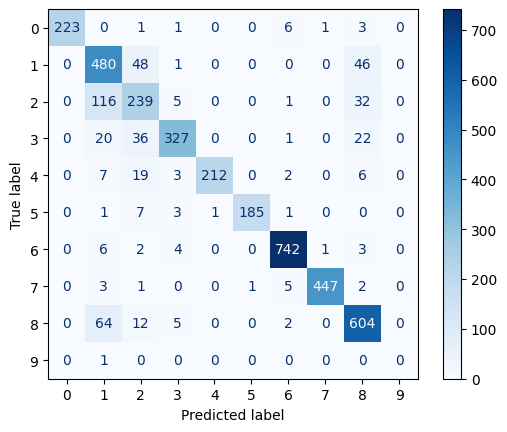

c:\Users\ivanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ivanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ivanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

,precision,recall,f1-score,support
0,1.000000,0.948936,0.973799,235.000000
1,0.687679,0.834783,0.754124,575.000000
2,0.654795,0.608142,0.630607,393.000000
3,0.936963,0.805419,0.866225,406.000000
4,0.995305,0.851406,0.917749,249.000000
5,0.994624,0.934343,0.963542,198.000000
6,0.976316,0.978892,0.977602,758.000000
7,0.995546,0.973856,0.984581,459.000000
8,0.841226,0.879185,0.859786,687.000000
9,0.000000,0.000000,0.000000,1.000000


AUC-ROC test: 0.9867
AUC-ROC train: 1.0000


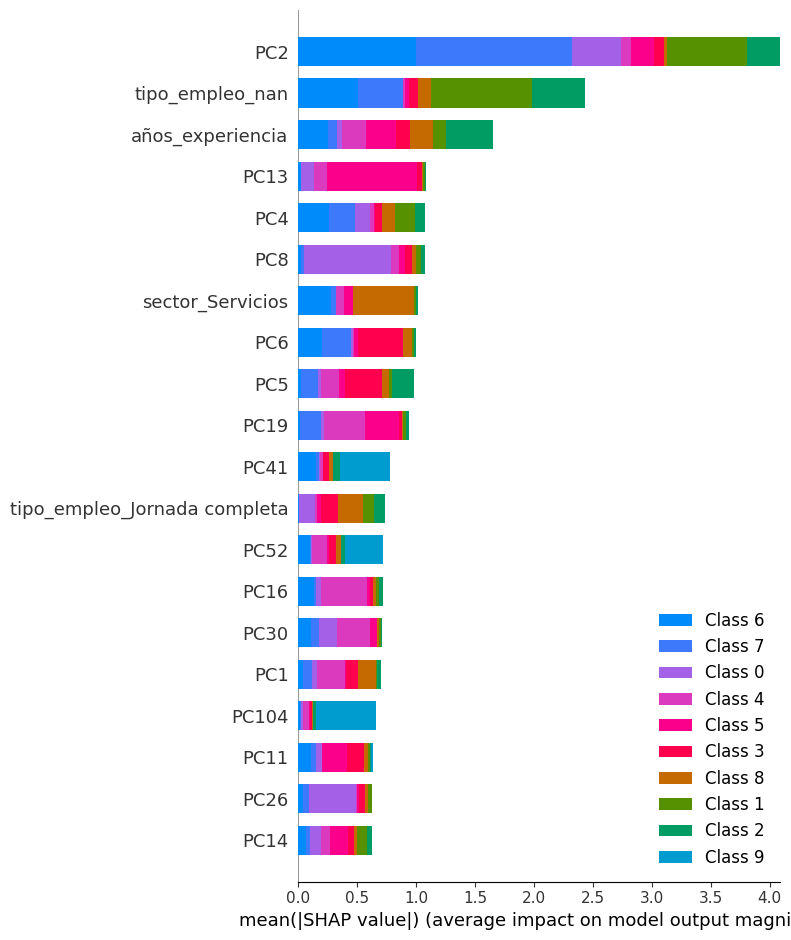

In [161]:
Xgb_set1 = joblib.load('../models/set_1_XGBClassifier.joblib')
resultados(Xgb_set1, X_train[sets_posibles[0]], X_test[sets_posibles[0]])

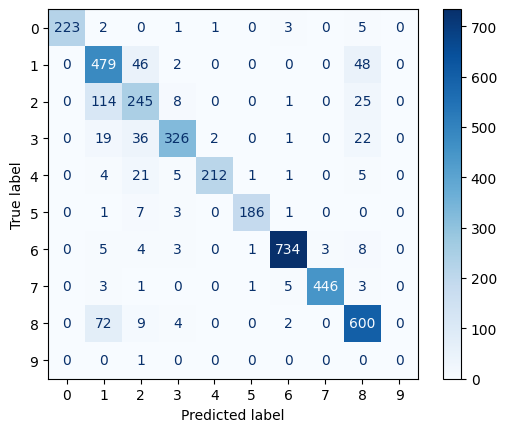

c:\Users\ivanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ivanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ivanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

,precision,recall,f1-score,support
0,1.000000,0.948936,0.973799,235.000000
1,0.685265,0.833043,0.751962,575.000000
2,0.662162,0.623410,0.642202,393.000000
3,0.926136,0.802956,0.860158,406.000000
4,0.986047,0.851406,0.913793,249.000000
5,0.984127,0.939394,0.961240,198.000000
6,0.981283,0.968338,0.974768,758.000000
7,0.993318,0.971678,0.982379,459.000000
8,0.837989,0.873362,0.855310,687.000000
9,0.000000,0.000000,0.000000,1.000000


AUC-ROC test: 0.9860
AUC-ROC train: 1.0000


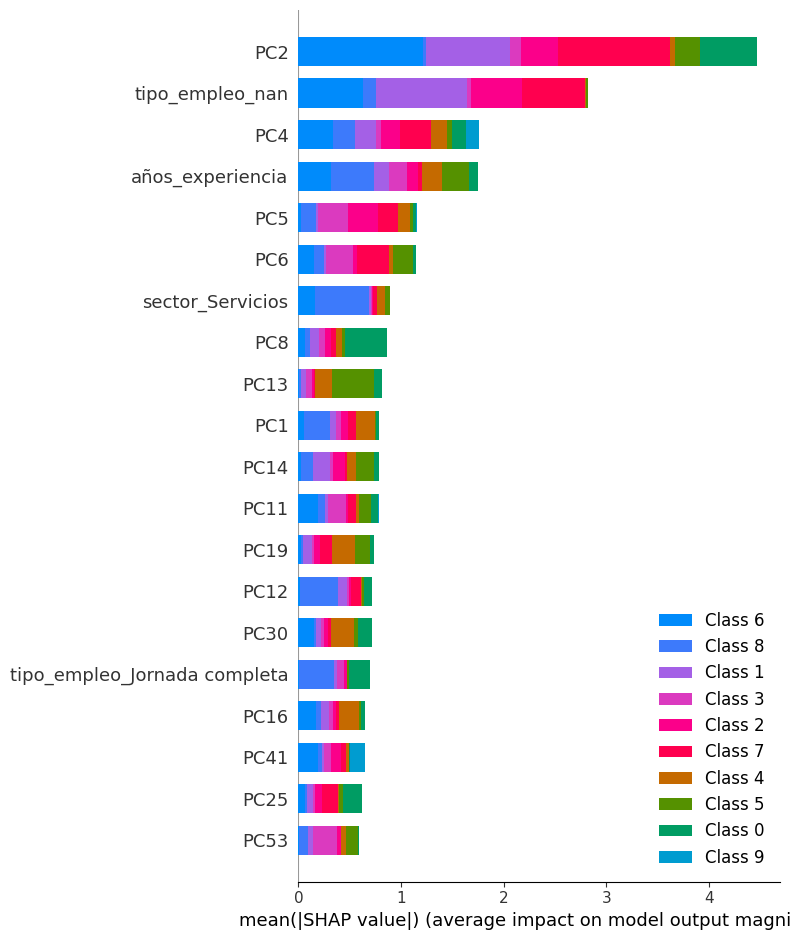

In [162]:
lgm_set1 = joblib.load('../models/set_1_LGBMClassifier.joblib') 
resultados(lgm_set1, X_train[sets_posibles[0]], X_test[sets_posibles[0]])

Los modelos están aprendiendo que que el tipo de empleo nulo es un buen predictor.

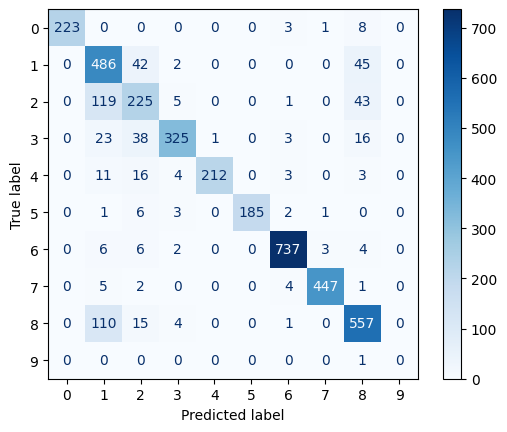

c:\Users\ivanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ivanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ivanb\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

,precision,recall,f1-score,support
0,1.000000,0.948936,0.973799,235.000000
1,0.638633,0.845217,0.727545,575.000000
2,0.642857,0.572519,0.605653,393.000000
3,0.942029,0.800493,0.865513,406.000000
4,0.995305,0.851406,0.917749,249.000000
5,1.000000,0.934343,0.966057,198.000000
6,0.977454,0.972296,0.974868,758.000000
7,0.988938,0.973856,0.981339,459.000000
8,0.821534,0.810771,0.816117,687.000000
9,0.000000,0.000000,0.000000,1.000000


AUC-ROC test: 0.9836
AUC-ROC train: 1.0000


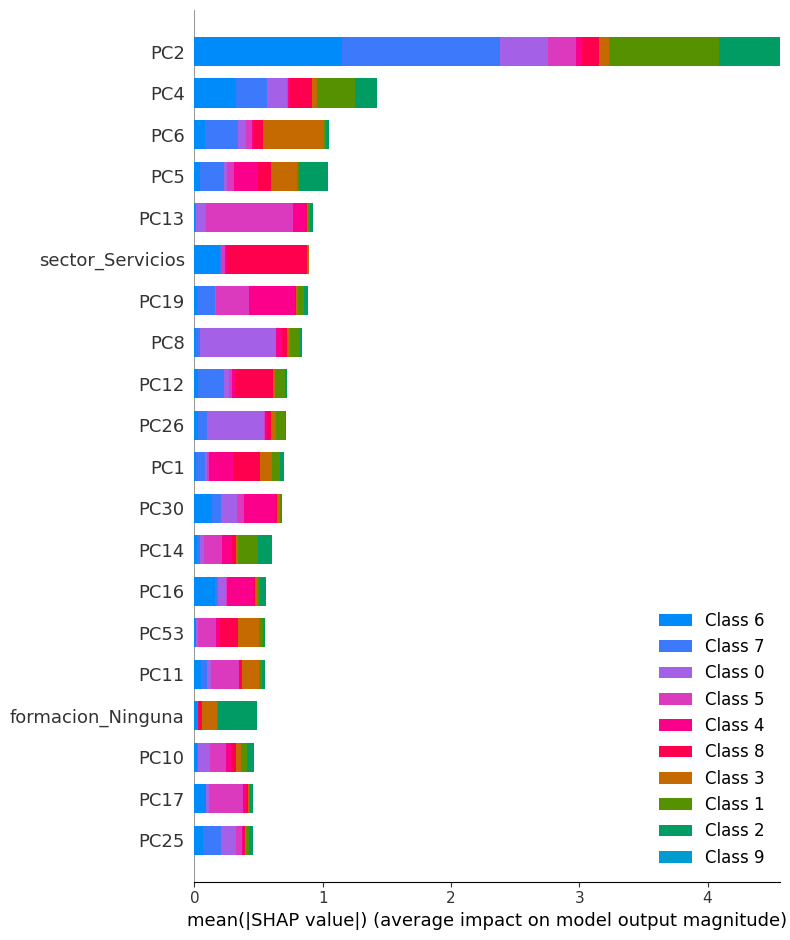

In [163]:
xgb_set3 = joblib.load('../models/set_3_XGBClassifier.joblib')
resultados(xgb_set3, X_train[sets_posibles[2]], X_test[sets_posibles[2]])